In [1]:
from src.utils.DataFolder import DataFolder
from src.ThetaSignal import ThetaSignal
from src.pipeline import emd_analysis

import yaml
import numpy as np
import pandas as pd

data_path = "/home/miranjo/phasic_tonic/data/processed"
config_path = "/home/miranjo/phasic_tonic/configs/test.yaml"

## Loading the arguments

In [2]:
with open(config_path, 'r') as f:
    args = yaml.safe_load(f)

fs                  = args.pop("fs")
f_theta             = (args.pop("f_theta_lower"), args.pop("f_theta_upper"))
f_lowpass           = args.pop("f_lowpass")
n_seconds_filter    = args.pop("n_seconds_filter")
n_seconds_theta     = args.pop("n_seconds_theta")
threshold_kwargs    = args.pop("threshold_kwargs")
skip_threshold      = args.pop("skip_threshold")

## Loading the dataset

In [3]:
remFolder = DataFolder(data_path)
print(remFolder)

DataFolder in '/home/miranjo/phasic_tonic/data/processed', contains 102 files.


# Runnning the analysis

### Sample LFP

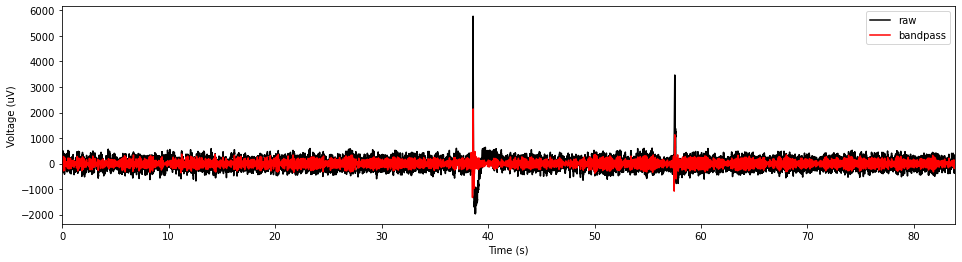

In [17]:
remData = remFolder[0]
arrays = remData["data"]
metadata = remData["metadata"]

sig = ThetaSignal(arrays[0], fs)
sig.filter('bandpass', f_theta, n_seconds_theta)
sig.plot()

In [133]:
sig.segment_cycles()

Phasic periods in the bandpass signal: 9
Periods: 
 [(149145, 151519)]
Tonic periods in the bandpass signal: 656
Periods: 
 [(291, 209423)]


In [134]:
df_ph = []
df_tc = []
df = []

for phasic in sig.get_phasic():
    df_ph = emd_analysis(phasic, sig.sampling_rate)["duration_samples"]
for tonic in sig.get_tonic():
    df_tc = emd_analysis(tonic, sig.sampling_rate)["duration_samples"]


Detected cycles before extraction:
<class 'emd.cycles.Cycles'> (10 cycles 1 metrics) 

Finished computing the cycles metrics

Cycles after extraction:
8
Detected cycles before extraction:
<class 'emd.cycles.Cycles'> (669 cycles 1 metrics) 

Finished computing the cycles metrics

Cycles after extraction:
594


In [139]:
(df_tc).sum()/2500

74.4048

In [58]:
df_tc.add_prefix("HC_")
df_ph.add_prefix("OC_")
df = pd.concat([df_ph, df_tc], axis=0)
df

0      285
1      281
2      278
3      263
4      252
      ... 
589    359
590    399
591    338
592    397
593    386
Name: duration_samples, Length: 602, dtype: int64

In [80]:
hc = np.zeros(len(df_tc), dtype=bool)
hc = pd.Series(hc, name="HC")
oc = pd.Series(np.ones(len(df_ph), dtype=bool), name="HC")
tonic_hc = pd.concat([df_tc, hc], axis=1)
tonic_oc = pd.concat([df_ph, oc], axis=1)
pd.concat([tonic_hc, tonic_oc], axis=0)

,duration_samples,HC
0,286,False
1,326,False
2,335,False
3,272,False
4,303,False
...,...,...
3,263,True
4,252,True
5,235,True
6,254,True


In [90]:
pd.DataFrame(columns=["duration_samples", "HC"])

,duration_samples,HC


<AxesSubplot:>

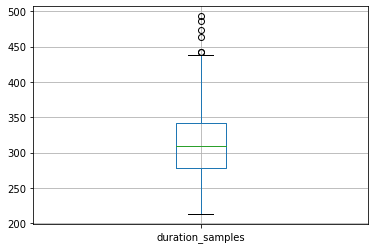

In [44]:
df.boxplot(column=["duration_samples"])

### Dataset

In [95]:
phasic_dur = pd.DataFrame(columns=["duration_samples", "HC"])
tonic_dur = pd.DataFrame(columns=["duration_samples", "HC"])

for sample in remFolder:
    lfpREMs = sample["data"]
    metadata = sample["metadata"]
    condition = metadata["condition"]
    
    if(condition == 'HC'):
        cond = True
    else:
        cond = False

    for lfpREM in lfpREMs:
        theta = ThetaSignal(lfpREM, fs)
        if(theta.duration >= 1875/2500): #Skip when the duration is less than ~0.75s
            theta.filter('lowpass', f_theta, n_seconds_filter)
            theta.segment_cycles()
        else:
            break

        for tonic in theta.get_tonic():
            df = emd_analysis(tonic, theta.sampling_rate)["duration_samples"]
            mask = pd.Series(np.ones(len(df), dtype=bool), name="HC") 
            dur_hc = pd.concat([df, mask*cond], axis=1)
            tonic_dur = pd.concat([tonic_dur, dur_hc], axis=0)

        if (theta.phasic == None):
            break
        else:
            for phasic in theta.get_phasic():
                df = emd_analysis(phasic, theta.sampling_rate)["duration_samples"]
                mask = pd.Series(np.ones(len(df), dtype=bool), name="HC") 
                dur_hc = pd.concat([df, mask*cond], axis=1)
                phasic_dur = pd.concat([phasic_dur, dur_hc], axis=0)

Phasic periods in the lowpass signal: 0
No phasic periods detected
Tonic periods in the lowpass signal: 663
Periods: 
 [(293, 209426)]
Detected cycles before extraction:
<class 'emd.cycles.Cycles'> (621 cycles 1 metrics) 

Finished computing the cycles metrics

Cycles after extraction:
518
Phasic periods in the lowpass signal: 0
No phasic periods detected
Tonic periods in the lowpass signal: 1144
Periods: 
 [(405, 386983)]
Detected cycles before extraction:
<class 'emd.cycles.Cycles'> (1111 cycles 1 metrics) 

Finished computing the cycles metrics

Cycles after extraction:
950
Phasic periods in the lowpass signal: 0
No phasic periods detected
Tonic periods in the lowpass signal: 748
Periods: 
 [(139, 243773)]
Detected cycles before extraction:
<class 'emd.cycles.Cycles'> (716 cycles 1 metrics) 

Finished computing the cycles metrics

Cycles after extraction:
571
Phasic periods in the lowpass signal: 37
Periods: 
 [(106769, 108988), (171557, 174665), (267131, 272657)]
Tonic periods in t

<AxesSubplot:title={'center':'duration_samples'}, xlabel='HC'>

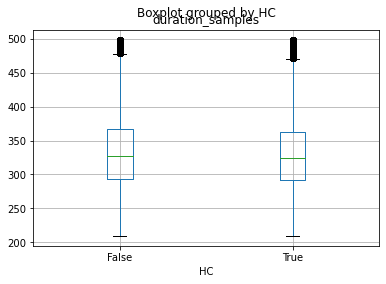

In [131]:
tonic_dur.boxplot(column="duration_samples", by="HC")

<AxesSubplot:title={'center':'duration_samples'}, xlabel='HC'>

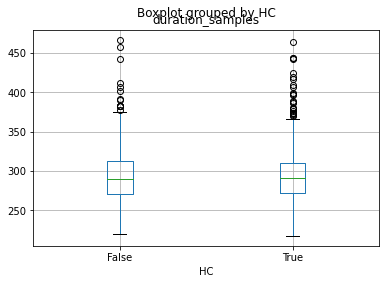

In [132]:
phasic_dur.boxplot(column="duration_samples", by="HC")

In [150]:
tonic_dur

,duration_samples,HC
0,289,False
1,278,False
2,360,False
3,264,False
4,341,False
...,...,...
6,318,True
7,292,True
8,373,True
9,399,True
